### Part A

In [34]:
# HERE YOU WILL WRITE CODE TO TEST A NUMBER OF PREDICTORS
# AND FINALLY CHOOSE AND TRAIN THE PREDICTOR THAT YOU WILL BE USING FOR PART B

# Importing Required Packages

In [35]:
import pandas as pd
from pandas import read_csv
import numpy as np
from numpy import mean, std, absolute
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder #Import Label Encoder for Conversion of object values to Integer values.
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RepeatedKFold
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

# Loading the dataset

In [36]:
train_data = pd.read_csv('CE802_P3_Data.csv')
train_data.head()

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,...,F28,F29,F30,F31,F32,F33,F34,F35,F36,Target
0,-69.21,16536.84,6,Europe,-16720.42,735.74,22.14,15.48,Medium,124.05,...,-506.31,-3077.82,15.35,-53.04,-112.43,-2537.30,4.06,40.32,3.18,2697.84
1,-168.67,28434.21,12,UK,-8070.93,91.35,-1.86,18.60,Very high,57.78,...,-731.28,-4559.70,20.74,-36.44,-44.06,-2384.48,33.52,176.98,5.81,3632.57
2,-76.19,22895.97,18,Europe,-12126.02,145.64,-68.28,14.22,High,-65.88,...,-355.08,-3965.13,16.65,-76.06,-81.66,-2225.42,28.90,165.00,2.85,2257.40
3,-103.19,22926.51,12,Europe,-10050.95,218.39,-40.58,14.99,Very high,132.12,...,-518.52,-1509.87,21.99,-128.34,-142.53,-1320.10,1.12,211.88,2.96,1785.03
4,-49.84,-4224.12,6,Rest,-10197.84,-346.17,-47.04,8.92,High,113.31,...,-576.60,-1907.67,14.10,72.98,-75.83,-2019.04,8.16,154.32,2.92,1063.23


In [37]:
train_data.shape

(1500, 37)

In [38]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 37 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F1      1500 non-null   float64
 1   F2      1500 non-null   float64
 2   F3      1500 non-null   int64  
 3   F4      1500 non-null   object 
 4   F5      1500 non-null   float64
 5   F6      1500 non-null   float64
 6   F7      1500 non-null   float64
 7   F8      1500 non-null   float64
 8   F9      1500 non-null   object 
 9   F10     1500 non-null   float64
 10  F11     1500 non-null   float64
 11  F12     1500 non-null   float64
 12  F13     1500 non-null   float64
 13  F14     1500 non-null   float64
 14  F15     1500 non-null   float64
 15  F16     1500 non-null   float64
 16  F17     1500 non-null   float64
 17  F18     1500 non-null   float64
 18  F19     1500 non-null   float64
 19  F20     1500 non-null   float64
 20  F21     1500 non-null   float64
 21  F22     1500 non-null   float64
 22  

# Exploatory Data Analysis

## Converting Object Variables to Numerical Variables 

In [39]:
train_data.dtypes

F1        float64
F2        float64
F3          int64
F4         object
F5        float64
F6        float64
F7        float64
F8        float64
F9         object
F10       float64
F11       float64
F12       float64
F13       float64
F14       float64
F15       float64
F16       float64
F17       float64
F18       float64
F19       float64
F20       float64
F21       float64
F22       float64
F23       float64
F24       float64
F25       float64
F26         int64
F27       float64
F28       float64
F29       float64
F30       float64
F31       float64
F32       float64
F33       float64
F34       float64
F35       float64
F36       float64
Target    float64
dtype: object

In [40]:
#Converting Object values to Numerical values
LE = LabelEncoder()

train_data['F4'] = LE.fit_transform(train_data['F4'])
train_data['F9'] = LE.fit_transform(train_data['F9'])

In [41]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 37 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F1      1500 non-null   float64
 1   F2      1500 non-null   float64
 2   F3      1500 non-null   int64  
 3   F4      1500 non-null   int32  
 4   F5      1500 non-null   float64
 5   F6      1500 non-null   float64
 6   F7      1500 non-null   float64
 7   F8      1500 non-null   float64
 8   F9      1500 non-null   int32  
 9   F10     1500 non-null   float64
 10  F11     1500 non-null   float64
 11  F12     1500 non-null   float64
 12  F13     1500 non-null   float64
 13  F14     1500 non-null   float64
 14  F15     1500 non-null   float64
 15  F16     1500 non-null   float64
 16  F17     1500 non-null   float64
 17  F18     1500 non-null   float64
 18  F19     1500 non-null   float64
 19  F20     1500 non-null   float64
 20  F21     1500 non-null   float64
 21  F22     1500 non-null   float64
 22  

## Dealing with Missing data 

In [42]:
train_data.isnull().sum()

F1        0
F2        0
F3        0
F4        0
F5        0
F6        0
F7        0
F8        0
F9        0
F10       0
F11       0
F12       0
F13       0
F14       0
F15       0
F16       0
F17       0
F18       0
F19       0
F20       0
F21       0
F22       0
F23       0
F24       0
F25       0
F26       0
F27       0
F28       0
F29       0
F30       0
F31       0
F32       0
F33       0
F34       0
F35       0
F36       0
Target    0
dtype: int64

## Dealing with Data Duplicates 

In [43]:
train_data.duplicated().sum()

0

## Handling Outliers 

<AxesSubplot:>

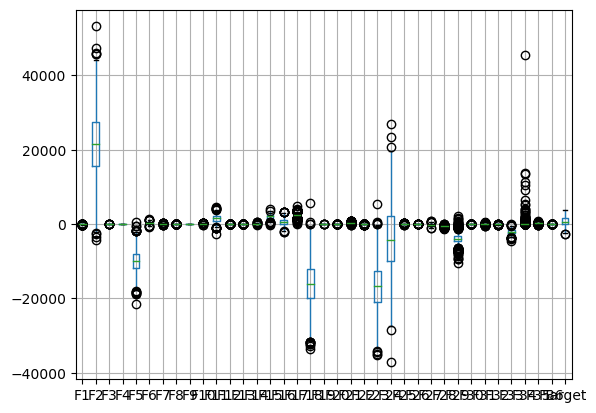

In [66]:
train_data.boxplot()

# Collinearity

In [45]:
train_data.corr()

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,...,F28,F29,F30,F31,F32,F33,F34,F35,F36,Target
F1,1.000000,0.000579,0.012399,0.010487,-0.044879,-0.030989,0.002640,-0.020460,-0.016969,0.005344,...,-0.040706,0.044032,-0.036008,0.011514,-0.045975,0.030663,-0.001780,-0.017487,-0.000790,-0.041725
F2,0.000579,1.000000,-0.004257,-0.006400,-0.090960,0.002472,0.019758,-0.032269,-0.009242,-0.000434,...,0.040973,-0.017642,-0.028977,-0.024948,-0.002547,-0.000665,-0.026167,-0.003642,0.057645,-0.001184
F3,0.012399,-0.004257,1.000000,0.004117,0.010405,-0.026571,0.045526,-0.007365,0.039024,0.000812,...,-0.025076,0.035053,-0.010380,0.037912,0.007139,-0.039338,-0.014514,0.014357,-0.001385,-0.330411
F4,0.010487,-0.006400,0.004117,1.000000,0.023977,-0.001503,-0.019175,0.048432,-0.003963,0.017552,...,-0.022588,-0.054330,-0.049761,0.024104,-0.005918,0.020885,0.015075,-0.034425,-0.026163,0.043389
F5,-0.044879,-0.090960,0.010405,0.023977,1.000000,-0.003659,0.040660,0.035496,-0.008635,-0.020545,...,0.003888,-0.016429,-0.011481,-0.027860,-0.018259,0.052275,-0.010488,0.018190,-0.005731,-0.004574
F6,-0.030989,0.002472,-0.026571,-0.001503,-0.003659,1.000000,0.004988,0.003595,-0.010052,0.020047,...,-0.040740,-0.027667,0.009650,-0.000538,-0.025911,-0.035298,-0.004316,0.006775,-0.022358,0.078041
F7,0.002640,0.019758,0.045526,-0.019175,0.040660,0.004988,1.000000,-0.020938,0.038492,0.009249,...,0.007659,0.007537,0.000716,0.030388,-0.065799,0.022430,0.012447,0.024263,0.024505,-0.018111
F8,-0.020460,-0.032269,-0.007365,0.048432,0.035496,0.003595,-0.020938,1.000000,0.016864,-0.015232,...,0.034131,0.013936,-0.014811,-0.012743,-0.031303,0.059178,-0.001447,-0.004737,0.019184,-0.050519
F9,-0.016969,-0.009242,0.039024,-0.003963,-0.008635,-0.010052,0.038492,0.016864,1.000000,-0.002250,...,0.009171,0.041917,0.001725,-0.002261,0.001632,0.017766,0.022381,-0.010334,0.062089,-0.167085
F10,0.005344,-0.000434,0.000812,0.017552,-0.020545,0.020047,0.009249,-0.015232,-0.002250,1.000000,...,-0.028919,0.023425,-0.013917,-0.051200,-0.075687,-0.020058,0.004091,0.034326,-0.021132,0.010754


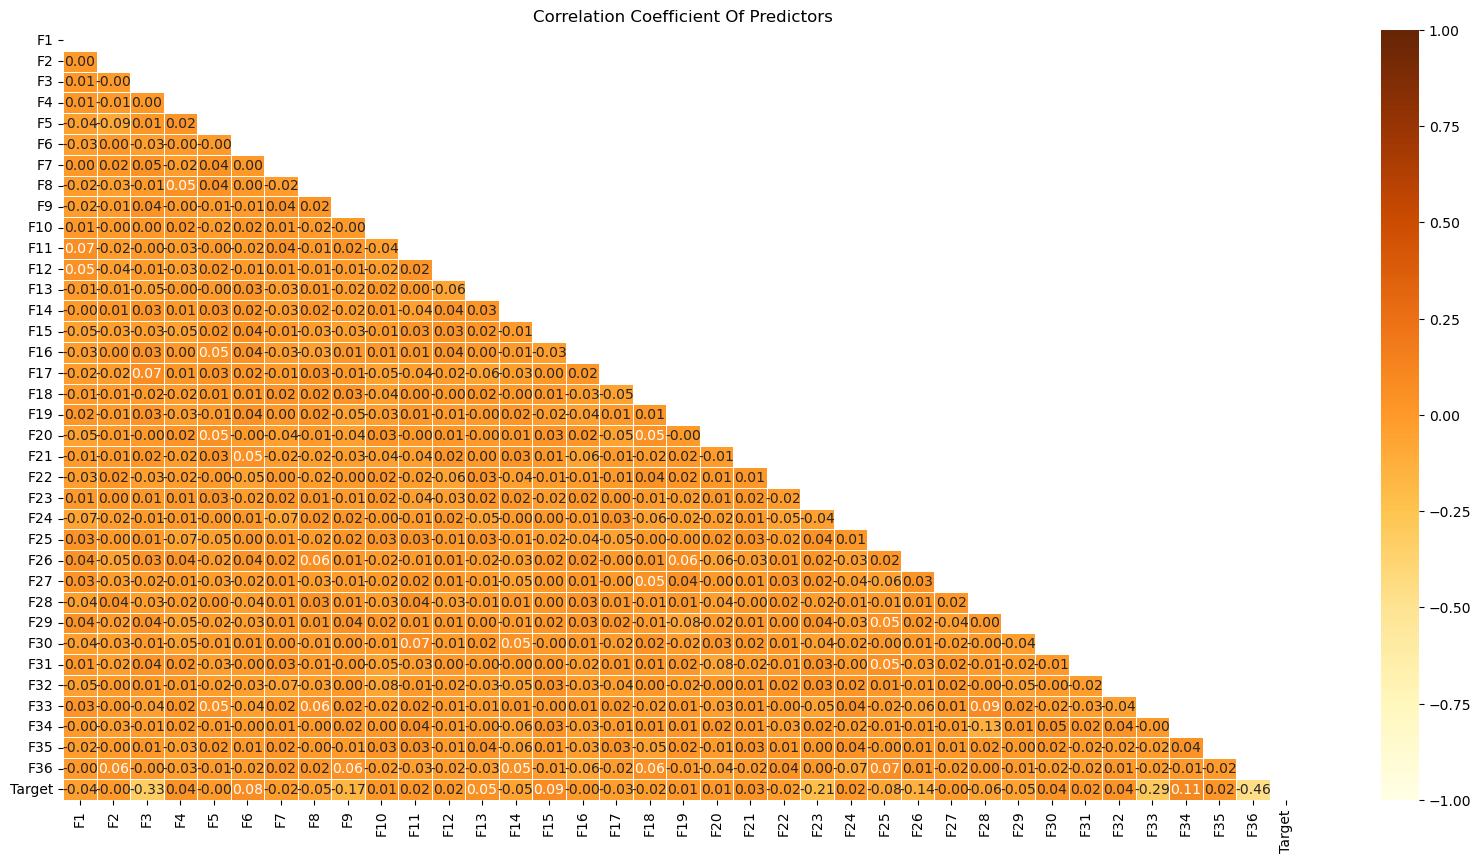

In [46]:
# set figure size
plt.figure(figsize=(20,10))

# Generate a mask to onlyshow the bottom triangle
mask = np.triu(np.ones_like(train_data.corr(), dtype=bool))

# generate heatmap
sns.heatmap(train_data.corr(), annot=True, mask=mask, vmin=-1, vmax=1, linewidths=0.5, fmt=".2f", cmap="YlOrBr")
plt.title('Correlation Coefficient Of Predictors')
plt.show()

# Feature Selection

In [47]:
#split dataset in features and target variable
X = train_data.drop('Target', axis=1)
Y = train_data['Target']

#Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

# Model Building

## Linear Regression Model 

In [48]:
#Define Linear Regression Model
Linear_regressor = LinearRegression()

#Fit the model
Linear_regressor= Linear_regressor.fit(X_train, y_train)

#Make a prediction
y_LR_pred = Linear_regressor.predict(X_test)

### Evaluation of the model 

In [49]:
# Calculating the Mean Squared Error
print("The Mean Squared Error for the Linear Regression Model is: ",mean_squared_error(y_test, y_LR_pred))

#calculate R-squared of regression model
r_squared = Linear_regressor.score(X_test,y_test)

#view R-squared value
print("The R-squared value for the Linear Reression model is: ", r_squared)

# Calculating the Mean Absolute Error
print("The mean Absolute Error for the Linear Regression Model is: ", mean_absolute_error(y_test, y_LR_pred))

The Mean Squared Error for the Linear Regression Model is:  693030.7252761628
The R-squared value for the Linear Reression model is:  0.5549947731138285
The mean Absolute Error for the Linear Regression Model is:  671.075948717528


### Visualization of Actual and predicted values  

In [50]:
pd.DataFrame({'Actual': y_test, 'Predicted': y_LR_pred}).head()

,Actual,Predicted
471,-611.04,250.817472
9,598.78,789.468565
1499,509.97,251.700523
54,203.95,1287.538763
1411,2736.69,1831.942641


C:\Users\heman\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)
C:\Users\heman\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)


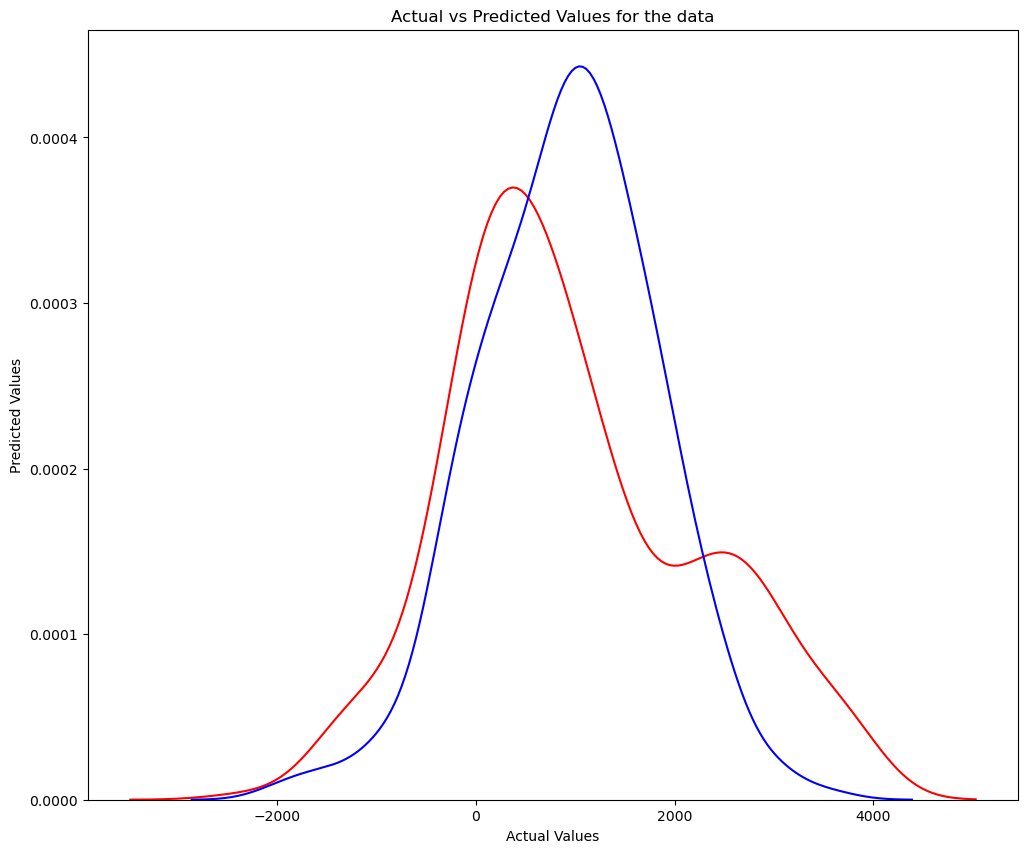

In [51]:
width = 12
height = 10
plt.figure(figsize=(width, height))


ax1 = sns.distplot(y_test, hist=False, color="r", label="Actual Value")
sns.distplot(y_LR_pred, hist=False, color="b", label="Predicted Values" , ax=ax1)


plt.title('Actual vs Predicted Values for the data')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

plt.show()

## Random Forest Regression Model 

In [52]:
#Define Random Forest Regression Model
RF_regressor = RandomForestRegressor()

#Fit the model
RF_regressor = RF_regressor.fit(X_train, y_train)

#Make a prediction
y_RF_pred= RF_regressor.predict(X_test)

### Evaluation of the model 

In [53]:
# Calculating the Mean Squared Error
print("The Mean Squared Error for the Random Fores Model is: ",mean_squared_error(y_test, y_RF_pred))

#calculate R-squared of regression model
r_squared = RF_regressor.score(X_test,y_test)

#view R-squared value
print("The R-squared value for the Linear Reression model is: ", r_squared)

# Calculating the Mean Absolute Error
print("The mean Absolute Error for the Linear Regression Model is: ", mean_absolute_error(y_test, y_RF_pred))

The Mean Squared Error for the Random Fores Model is:  570278.6964543816
The R-squared value for the Linear Reression model is:  0.6338156571587708
The mean Absolute Error for the Linear Regression Model is:  588.1181356666667


### Visualization of Actual and predicted values 

In [54]:
pd.DataFrame({'Actual': y_test, 'Predicted': y_RF_pred}).head()

,Actual,Predicted
471,-611.04,498.7182
9,598.78,281.6208
1499,509.97,1519.5905
54,203.95,379.2175
1411,2736.69,2053.3134


C:\Users\heman\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)
C:\Users\heman\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)


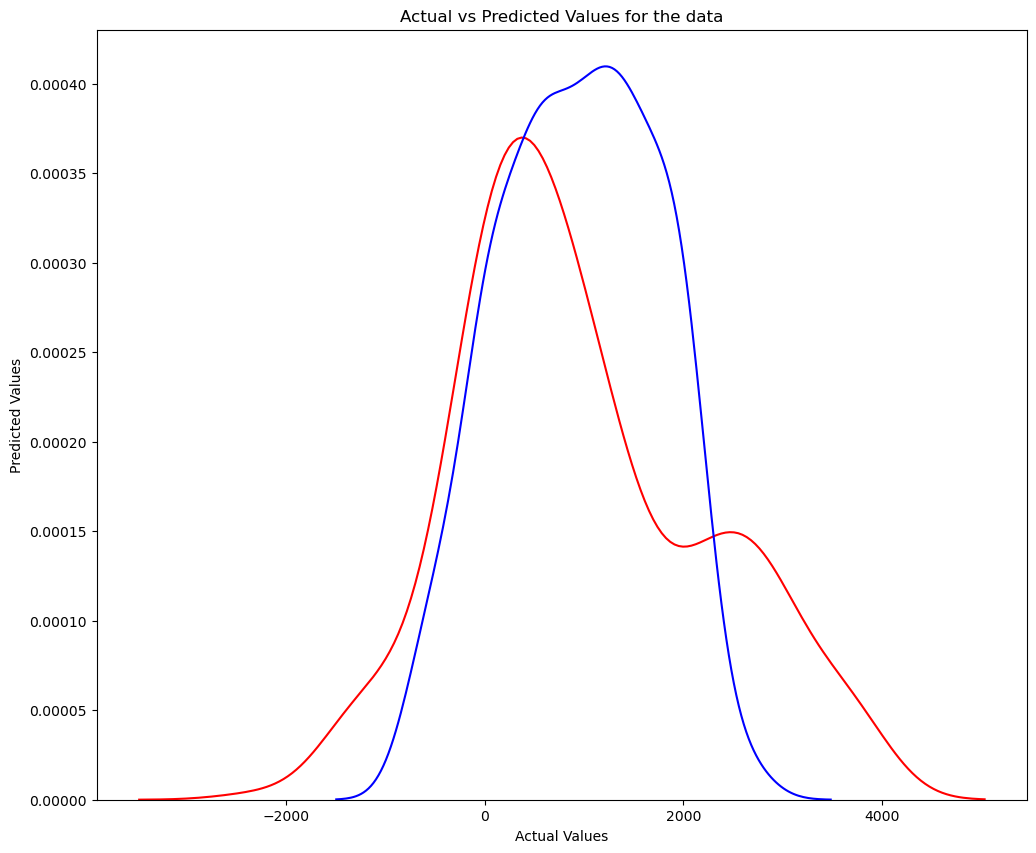

In [55]:
width = 12
height = 10
plt.figure(figsize=(width, height))


ax1 = sns.distplot(y_test, hist=False, color="r", label="Actual Value")
sns.distplot( y_RF_pred, hist=False, color="b", label="Predicted Values" , ax=ax1)


plt.title('Actual vs Predicted Values for the data')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

plt.show()

## Lasso Regression 

In [56]:
# define model
Lasso_regressor = Lasso(alpha=1.0)

# fit model
Lasso_regressor = Lasso_regressor.fit(X_train, y_train)

# make a prediction
y_LaR_pred = Lasso_regressor.predict(X_test)

### Evaluation of the model 

In [57]:
# Calculating the Mean Squared Error
print("The Mean Squared Error for the Lasso regression Model is: ",mean_squared_error(y_test, y_LaR_pred))

#calculate R-squared of regression model
r_squared = Lasso_regressor.score(X_test,y_test)

#view R-squared value
print("The R-squared value for the Linear Reression model is: ", r_squared)

# Calculating the Mean Absolute Error
print("The mean Absolute Error for the Linear Regression Model is: ", mean_absolute_error(y_test, y_LaR_pred))

The Mean Squared Error for the Lasso regression Model is:  693091.4061659694
The R-squared value for the Linear Reression model is:  0.5549558090215434
The mean Absolute Error for the Linear Regression Model is:  670.982051509583


### Visualization of Actual and predicted values 

In [58]:
pd.DataFrame({'Actual': y_test, 'Predicted': y_LaR_pred}).head()

,Actual,Predicted
471,-611.04,253.292768
9,598.78,788.660336
1499,509.97,251.555022
54,203.95,1286.346941
1411,2736.69,1831.544340


C:\Users\heman\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)
C:\Users\heman\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)


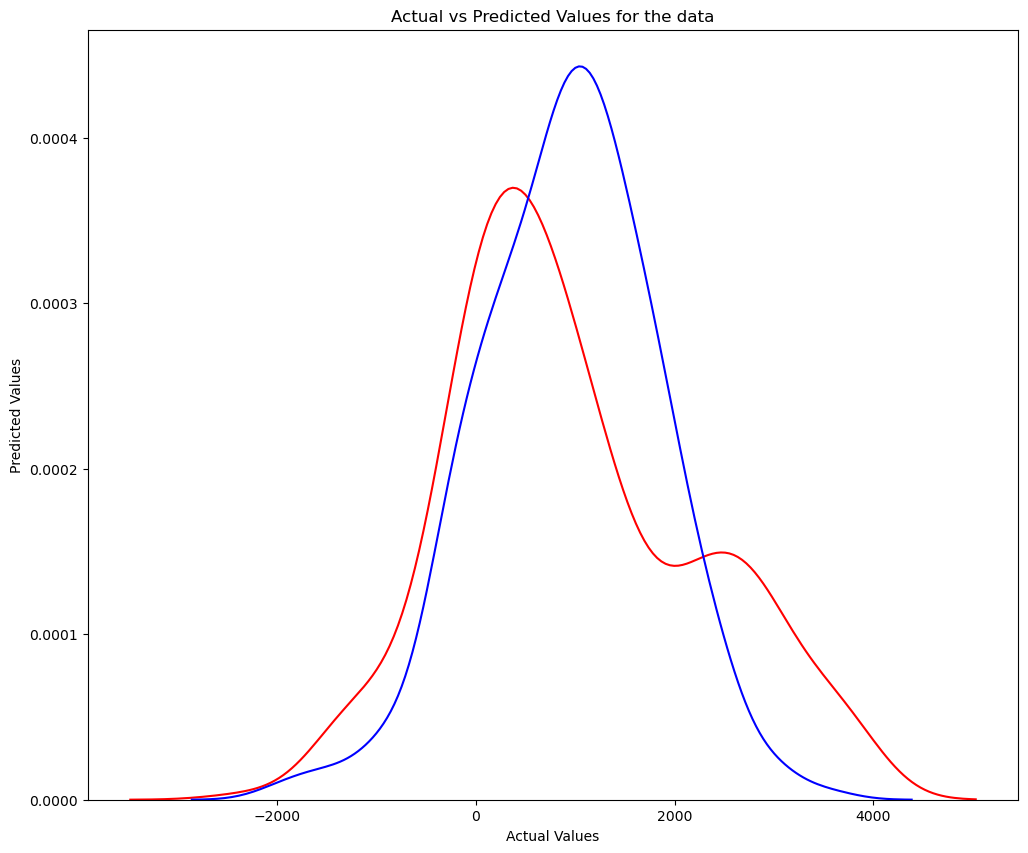

In [59]:
width = 12
height = 10
plt.figure(figsize=(width, height))


ax1 = sns.distplot(y_test, hist=False, color="r", label="Actual Value")
sns.distplot(y_LaR_pred, hist=False, color="b", label="Predicted Values" , ax=ax1)


plt.title('Actual vs Predicted Values for the data')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

plt.show()


### Cross Validation 

In [60]:
# define model
model = Lasso(alpha=1.0)
# define model evaluation method
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
# evaluate model
scores = cross_val_score(model, X_train, y_train, scoring='neg_mean_squared_error', cv=cv, n_jobs=-1)
# force scores to be positive
scores = absolute(scores)
print('Mean MSE: %.3f and Standard devation: %.3f' % (mean(scores), std(scores)))

Mean MSE: 868103.181 and Standard devation: 415683.012


##  Decision Tress Regressor

In [61]:
#create a regressor object
DT_regressor = DecisionTreeRegressor(random_state=0) 
  
#fit the regressor with X and Y data
DT_regressor = DT_regressor.fit(X_train, y_train)

# test the output by changing values, like 3750
y_DTR_pred = DT_regressor.predict(X_test)

### Evaluation of the Model 

In [62]:
# Calculating the Mean Squared Error
print("The Mean Squared Error for the Decision Tree Regression Model is: ",mean_squared_error(y_test, y_DTR_pred))

#calculate R-squared of regression model
r_squared = DT_regressor.score(X_test,y_test)

#view R-squared value
print("The R-squared value for the Decision Tree Regression model is: ", r_squared)

# Calculating the Mean Absolute Error
print("The mean Absolute Error for the Decision Tree Regression Model is: ", mean_absolute_error(y_test, y_DTR_pred))

The Mean Squared Error for the Decision Tree Regression Model is:  1281214.6075253333
The R-squared value for the Decision Tree Regression model is:  0.17731324699277562
The mean Absolute Error for the Decision Tree Regression Model is:  870.3688


### Visualization of Actual and predicted values 

In [63]:
pd.DataFrame({'Actual': y_test, 'Predicted': y_DTR_pred}).head()

,Actual,Predicted
471,-611.04,620.66
9,598.78,370.75
1499,509.97,1172.44
54,203.95,469.31
1411,2736.69,3367.63


C:\Users\heman\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)
C:\Users\heman\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)


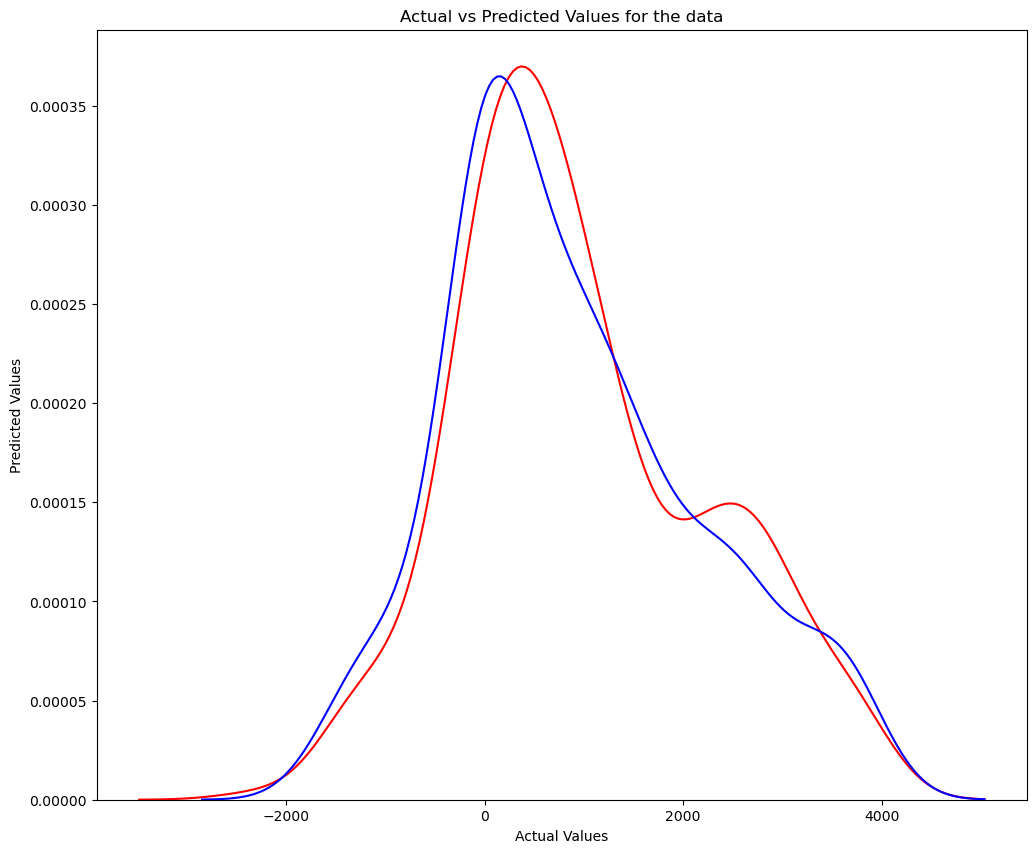

In [64]:
width = 12
height = 10
plt.figure(figsize=(width, height))


ax1 = sns.distplot(y_test, hist=False, color="r", label="Actual Value")
sns.distplot( y_DTR_pred, hist=False, color="b", label="Predicted Values" , ax=ax1)


plt.title('Actual vs Predicted Values for the data')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

plt.show()

### Part B

In [65]:
# HERE YOU WILL USE THIS TEMPLATE TO SAVE THE PREDICTIONS ON THE TEST SET

# Load the test data
test_df = pd.read_csv('CE802_P3_Test.csv')

# Make sure you work on a copy
test_data = test_df.iloc[:,:-1].copy()

#Converting String values to Integer Values
LE = LabelEncoder()

test_data['F4'] = LE.fit_transform(test_data['F4'])
test_data['F9'] = LE.fit_transform(test_data['F9'])

#make a prediction
predicted = RF_regressor.predict(test_data) # CHANGE HERE -- use your previously trained predictor and apply it to test_data
                # (test_data can be modified if needed but make sure you don't change the order of the rows)...

# Replace the last (empty) column with your prediction
test_df.iloc[:,-1] = predicted

# Save to the destination file
test_df.to_csv('CE802_P3_Test_Predictions.csv', index=False, float_format='%.8g')

# IMPORTANT!! Make sure only the last column has changed
assert pd.read_csv('CE802_P3_Test.csv').iloc[:,:-1].equals(pd.read_csv('CE802_P3_Test_Predictions.csv').iloc[:,:-1])